# Evaluation

Calls `src/evaluate.py` functions. Test-set evaluation only when Task 5.1 is reached.
No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.evaluate import (
    compute_metrics, compute_sector_metrics, compare_models,
    run_test_evaluation, compute_rank_ic, summarize_rank_ic,
)

In [2]:
import json
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.graphs import build_all_sector_graphs

# Load data artifacts
weekly_rv = pd.read_parquet(Path(config.DATA_RAW_DIR) / 'weekly_rv.parquet')
target    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits    = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
tickers   = target.columns.tolist()

with open(Path(config.DATA_RAW_DIR) / 'sector_history.json') as f:
    sector_history = json.load(f)

# Reconstruct 3D feature tensor — same pattern as 04_gnn_models.ipynb
meta          = json.load(open(Path(config.DATA_FEATURES_DIR) / 'features_meta.json'))
feature_names = meta['feature_names']
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'features.parquet')
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()
ticker_order    = {t: i for i, t in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks  = target.shape[0]
n_stocks = target.shape[1]
n_feats  = len(feature_names)
features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
week_index  = target.index

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'features_3d: {features_3d.shape}  target: {target.shape}')
print(f'tickers: {len(tickers)}  device: {device}')
print(f'Test weeks: {splits[splits["split"] == "test"]["week"].nunique()}')

features_3d: (572, 465, 10)  target: (572, 465)
tickers: 465  device: cuda
Test weeks: 103


In [3]:
# Build sector graphs for all years (includes 2024 and 2025 for the test split)
sector_graphs = build_all_sector_graphs(
    tickers=tickers,
    sector_history=sector_history,
    years=range(2015, 2026),
)
print(f'Sector graphs built for {len(sector_graphs)} years')

# Load static Granger edge index from saved parquet
granger_df         = pd.read_parquet(Path(config.DATA_GRAPHS_DIR) / 'granger_edges.parquet')
granger_edge_index = torch.tensor(
    [granger_df['src'].values, granger_df['dst'].values], dtype=torch.long
)
print(f'Granger edges: {granger_edge_index.shape[1]:,}')

Saved 269890 total edges across 11 years to C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\sector_edges_by_year.parquet
Sector graphs built for 11 years
Granger edges: 13,886


C:\Users\Rylan Wade\AppData\Local\Temp\ipykernel_11548\2182597918.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  granger_edge_index = torch.tensor(


In [4]:
# Run test-set evaluation for all six models.
# Refits HAR on training data, loads all neural checkpoints, runs inference on 2024-2025.
# Saves test_preds_{key}.parquet (6 files) and ml_metrics_table.csv.
pooled_metrics, sector_metrics = run_test_evaluation(
    weekly_rv=weekly_rv,
    target_df=target,
    features=features_3d,
    week_index=week_index,
    splits=splits,
    tickers=tickers,
    sector_history=sector_history,
    sector_graphs=sector_graphs,
    granger_edge_index=granger_edge_index,
    device=device,
)
print('Evaluation complete.')

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:289: UserWarning: GNNModel.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Evaluation complete.


In [5]:
from pathlib import Path
from src.evaluate import build_gnn_ensemble_preds, compute_metrics

results_dir = Path(config.DATA_RESULTS_DIR)

# Build ensemble predictions from the three GNN parquets saved above.
# Must be called after run_test_evaluation() so the input parquets exist.
ensemble_preds = build_gnn_ensemble_preds(results_dir)

# Compute ML metrics and directional accuracy for the ensemble.
test_weeks  = splits.loc[splits['split'] == 'test', 'week']
target_test = target.reindex(test_weeks)
rv_test     = weekly_rv.reindex(test_weeks)

y_true = target_test.values
y_pred = ensemble_preds.reindex(target_test.index).values
y_rv   = rv_test.values

metrics = compute_metrics(y_true, y_pred)
valid   = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_rv))
metrics['da'] = float(np.mean(
    np.sign(y_pred[valid] - y_rv[valid]) == np.sign(y_true[valid] - y_rv[valid])
)) if valid.any() else float('nan')

# Append ensemble row and re-save so ml_metrics_table.csv stays authoritative.
ensemble_row = pd.DataFrame(
    [{'model': 'GNN-Ensemble', **metrics}]
).set_index('model')[['mse', 'mae', 'r2', 'da']]

pooled_metrics_full = pd.concat([pooled_metrics, ensemble_row]).sort_values('mse')
pooled_metrics_full.to_csv(results_dir / 'ml_metrics_table.csv')

print('Test set ML metrics (pooled, including GNN-Ensemble):')
print()
print(pooled_metrics_full.to_string(float_format=lambda x: f'{x:.6f}'))

GNN ensemble weights: gnn_corr=0.3667  gnn_sector=0.3147  gnn_granger=0.3186
Saved: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_ensemble.parquet
Test set ML metrics (pooled, including GNN-Ensemble):

                             mse      mae       r2       da
model                                                      
GNN-Ensemble            0.032012 0.112685 0.153091 0.700428
GNN-Correlation (tuned) 0.032191 0.107638 0.148354 0.712225
LSTM                    0.032424 0.109583 0.142188 0.708780
HAR per-stock           0.032858 0.112913 0.130697 0.707005
HAR pooled              0.033104 0.113265 0.124177 0.702954
GNN-Sector              0.033631 0.120846 0.110246 0.682242
GNN-Granger             0.033702 0.119049 0.108378 0.687942


In [6]:
# Sector breakdown for the best-performing model (lowest test MSE)
best_model = pooled_metrics.index[0]
print(f'Sector breakdown for: {best_model}')
print()
print(sector_metrics[best_model].to_string(float_format=lambda x: f'{x:.6f}'))

Sector breakdown for: GNN-Correlation (tuned)

                    sector  n_stocks      mse      mae        r2
0                  Unknown         1 0.194764 0.146023 -0.000458
1   Information Technology        72 0.052411 0.136304  0.177780
2   Communication Services        20 0.050795 0.127595  0.116665
3              Health Care        55 0.039486 0.111626  0.028993
4   Consumer Discretionary        51 0.032895 0.115110  0.139742
5                Materials        18 0.028561 0.111016  0.172948
6              Industrials        67 0.027882 0.108453  0.129973
7                   Energy        21 0.027007 0.103992  0.094282
8               Financials        68 0.023038 0.092731  0.100276
9         Consumer Staples        34 0.022878 0.090914  0.063610
10             Real Estate        29 0.014568 0.083905  0.025123
11               Utilities        29 0.014439 0.077628  0.134038


In [7]:
# Confirm all output files were saved
results_dir = Path(config.DATA_RESULTS_DIR)
print('Saved files:')
for key in ['har', 'har_pooled', 'lstm', 'gnn_corr', 'gnn_sector', 'gnn_granger']:
    p = results_dir / f'test_preds_{key}.parquet'
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KB)')
csv_path = results_dir / 'ml_metrics_table.csv'
print(f'  {csv_path.name}  ({csv_path.stat().st_size / 1024:.0f} KB)')

Saved files:
  test_preds_har.parquet  (700 KB)
  test_preds_har_pooled.parquet  (700 KB)
  test_preds_lstm.parquet  (490 KB)
  test_preds_gnn_corr.parquet  (491 KB)
  test_preds_gnn_sector.parquet  (491 KB)
  test_preds_gnn_granger.parquet  (491 KB)
  ml_metrics_table.csv  (1 KB)


## Experiment registry

Current machine-readable provenance registry for the frozen baseline model roster.

In [8]:
# REGISTRY_PREVIEW_CELL
from pathlib import Path
import pandas as pd
from IPython.display import display

registry_path = Path('../data/results/experiment_registry.csv')
registry = pd.read_csv(registry_path)
preview_cols = [
    'experiment_id',
    'model_name',
    'model_family',
    'graph_type',
    'loss_type',
    'feature_version',
    'graph_version',
    'checkpoint_path',
    'validation_metrics_path',
    'test_metrics_path',
    'portfolio_metrics_path',
]
display(registry[preview_cols])
print(f'Registry path: {registry_path.as_posix()}')
print(f'Registered experiments: {len(registry)}')


,experiment_id,model_name,model_family,graph_type,loss_type,feature_version,graph_version,checkpoint_path,validation_metrics_path,test_metrics_path,portfolio_metrics_path
0,baseline_har_per_stock,HAR per-stock,HAR,none,squared_error,har_realized_volatility_lags_v1,none,NaN,data/results/validation_summary.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
1,baseline_har_pooled,HAR pooled,HAR,none,squared_error,har_realized_volatility_lags_v1,none,NaN,data/results/validation_summary.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
2,baseline_lstm,LSTM,LSTM,none,mse,stock_features_v1,none,data/results/checkpoints/lstm_best.pt,data/results/lstm_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
3,baseline_gnn_correlation,GNN-Correlation,GNN,correlation,mse,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_hparam_best.pt,data/results/gnn_corr_th03_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
4,baseline_gnn_sector,GNN-Sector,GNN,sector,mse,stock_features_v1,sector_canonical_gics_labels_v1,data/results/checkpoints/gnn_sector_best.pt,data/results/gnn_sector_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
5,baseline_gnn_granger,GNN-Granger,GNN,granger,mse,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_best.pt,data/results/gnn_granger_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
6,baseline_gnn_ensemble,GNN-Ensemble,GNN ensemble,correlation+sector+granger,mse,stock_features_v1,correlation+sector+granger_v1,NaN,data/results/validation_summary.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
7,rankloss_gnn_correlation,Rank-loss GNN-Correlation,GNN,correlation,bpr_rank,stock_features_v1,correlation_threshold_0.3_lookback_252,data/results/checkpoints/gnn_corr_rankloss_bes...,data/results/gnn_corr_rankloss_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
8,rankloss_gnn_sector,Rank-loss GNN-Sector,GNN,sector,bpr_rank,stock_features_v1,sector_canonical_gics_labels_v1,data/results/checkpoints/gnn_sector_rankloss_b...,data/results/gnn_sector_rankloss_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."
9,rankloss_gnn_granger,Rank-loss GNN-Granger,GNN,granger,bpr_rank,stock_features_v1,granger_lag_5_bonferroni,data/results/checkpoints/gnn_granger_rankloss_...,data/results/gnn_granger_rankloss_val_loss.json,"[""data/results/ml_metrics_table.csv"",""data/res...","[""data/results/portfolio_metrics_table.csv"",""d..."


Registry path: ../data/results/experiment_registry.csv
Registered experiments: 15


In [9]:
# Rank IC — cross-sectional Spearman correlation between predicted and actual RV.
# All models are evaluated on the same 103 test weeks (2024-2025).
from src.evaluate import compute_rank_ic, summarize_rank_ic

results_dir = Path(config.DATA_RESULTS_DIR)
target_test = target.reindex(splits.loc[splits['split'] == 'test', 'week'])

pred_files = {
    'HAR per-stock':           'test_preds_har.parquet',
    'HAR pooled':              'test_preds_har_pooled.parquet',
    'LSTM':                    'test_preds_lstm.parquet',
    'GNN-Correlation (tuned)': 'test_preds_gnn_corr.parquet',
    'GNN-Sector':              'test_preds_gnn_sector.parquet',
    'GNN-Granger':             'test_preds_gnn_granger.parquet',
    'GNN-Ensemble':            'test_preds_gnn_ensemble.parquet',
}

ic_series_all: dict[str, pd.Series] = {}
ic_summary_rows: list[dict] = []

for model_name, fname in pred_files.items():
    preds = pd.read_parquet(results_dir / fname).reindex(target_test.index)
    ic    = compute_rank_ic(preds, target_test)
    ic_series_all[model_name] = ic
    summary = summarize_rank_ic(ic)
    ic_summary_rows.append({'model': model_name, **summary})

ic_table = (
    pd.DataFrame(ic_summary_rows)
    .set_index('model')
    .sort_values('mean_ic', ascending=False)
)
ic_table.to_csv(results_dir / 'rank_ic_table.csv')
print('Rank IC table saved.')
print()

Rank IC table saved.



Rank IC — test set (2024-2025), 103 weeks

                         mean_ic  ic_std  ic_tstat  ic_pvalue  ic_ir  n_weeks  pct_positive
model                                                                                      
LSTM                      0.4288  0.0983   44.2754     0.0000 4.3626      103        1.0000
GNN-Correlation (tuned)   0.4165  0.1211   34.9116     0.0000 3.4399      103        1.0000
GNN-Ensemble              0.4162  0.1164   36.3019     0.0000 3.5769      103        1.0000
HAR per-stock             0.4049  0.1166   35.2453     0.0000 3.4728      103        1.0000
HAR pooled                0.3923  0.1142   34.8820     0.0000 3.4370      103        1.0000
GNN-Sector                0.3826  0.1125   34.4998     0.0000 3.3994      103        1.0000
GNN-Granger               0.3749  0.1024   37.1755     0.0000 3.6630      103        1.0000



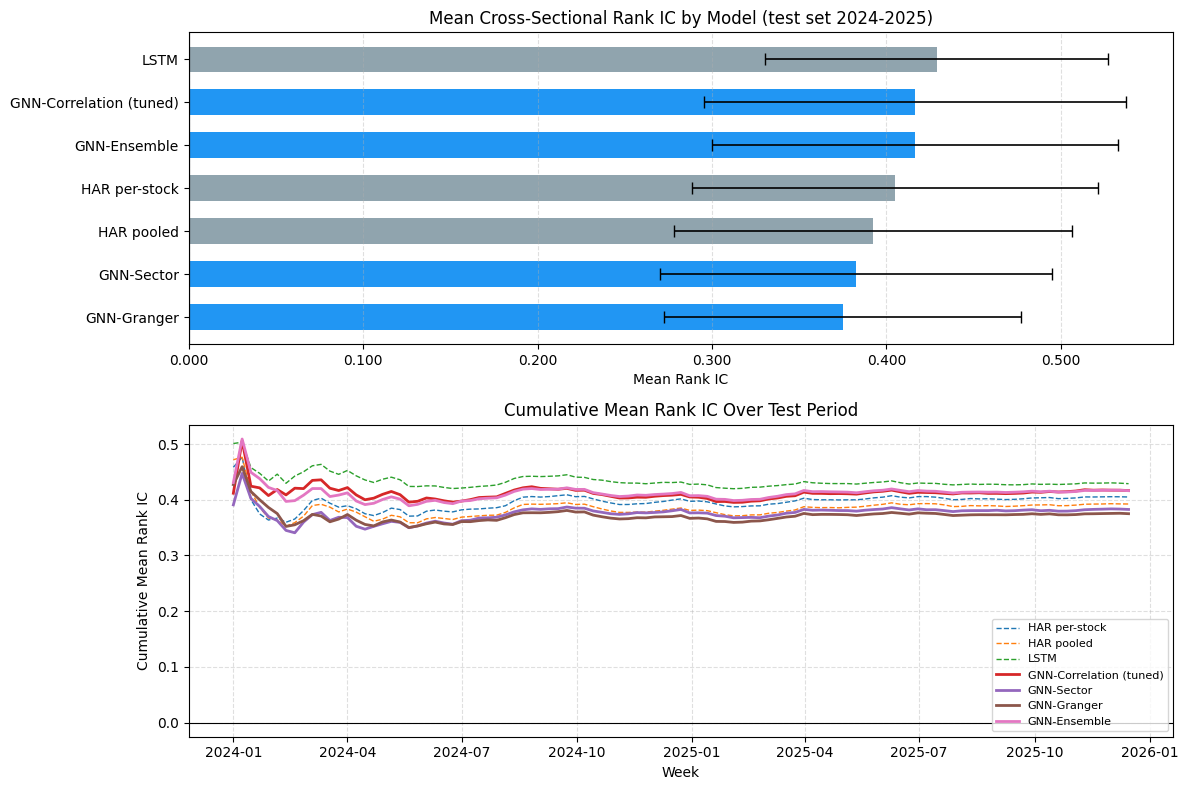

Saved: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\rank_ic_plot.png


In [10]:
# Display Rank IC summary table
print('Rank IC — test set (2024-2025), 103 weeks')
print()
print(ic_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()

# Plot cumulative weekly IC for all models
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax_bar = axes[0]
ax_line = axes[1]

# Bar chart: mean IC with error bars (+/- 1 std of the weekly IC series)
models  = ic_table.index.tolist()
means   = ic_table['mean_ic'].values
stds    = [ic_series_all[m].dropna().std(ddof=1) for m in models]
colors  = ['#2196F3' if 'GNN' in m else '#90A4AE' for m in models]

ax_bar.barh(models[::-1], means[::-1], xerr=stds[::-1], color=colors[::-1],
            error_kw={'elinewidth': 1.2, 'capsize': 4}, height=0.6)
ax_bar.axvline(0, color='black', linewidth=0.8)
ax_bar.set_xlabel('Mean Rank IC')
ax_bar.set_title('Mean Cross-Sectional Rank IC by Model (test set 2024-2025)')
ax_bar.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)

# Line chart: cumulative IC (running mean) over weeks
for model_name, ic_s in ic_series_all.items():
    lw   = 2.0 if 'GNN' in model_name else 1.0
    ls   = '-'  if 'GNN' in model_name else '--'
    cumulative_mean = ic_s.expanding().mean()
    ax_line.plot(cumulative_mean.index, cumulative_mean.values,
                 label=model_name, linewidth=lw, linestyle=ls)

ax_line.axhline(0, color='black', linewidth=0.8)
ax_line.set_xlabel('Week')
ax_line.set_ylabel('Cumulative Mean Rank IC')
ax_line.set_title('Cumulative Mean Rank IC Over Test Period')
ax_line.legend(fontsize=8, loc='lower right')
ax_line.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
fig_path = Path(config.DATA_RESULTS_DIR) / 'rank_ic_plot.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

What happened, mechanically

  On validation (2023): GNN-Correlation MSE = 0.01978, HAR = 0.02184 — a 9.4% gap.
  On test (2024-2025): GNN-Correlation MSE = 0.03331, HAR = 0.03286 — gap reversed, all models within 0.001 of each
  other.

  Two things are going on simultaneously:

  1. Every model got harder (distribution shift)

  All six MSEs jumped ~60% from validation to test. The validation year (2023) was relatively calm — steady recovery
  from the 2022 bear market. The test period (2024-2025) includes the AI-driven tech divergence, rate-cut cycle
  volatility, and periods where historical cross-stock relationships broke down. This affects everyone equally and
  doesn't explain the reversal alone.

  2. The GNN overfit to 2023 market structure specifically

  The GNN-Correlation model was tuned with 51 validation consultations — 3 threshold values, then 48 hyperparameter
  configurations, all selected on 2023. That's a lot of implicit adaptation to one year. The validation gap was real but
   partially reflects optimizing to 2023 conditions.

  More fundamentally: the correlation graph uses a 252-day rolling window. In 2024-2025, when AI bifurcated tech stocks
  from the rest of the market, the rolling window still incorporates 2023 and 2022 data, encoding relationships that no
  longer hold. The GNN propagates stale neighbor information, which can actively hurt predictions. An LSTM processing
  each stock independently sidesteps this.

  What this means for the paper

  This is not a disaster — it's a legitimate finding. A few things to note:

  1. DA tells a different story. GNN-Correlation has the best DA at 0.7155, despite ranking 4th on MSE. DA is directly
  relevant to portfolio construction (you want to overweight stocks that will be calm). Task 5.2 (portfolio backtest)
  may still show GNN-Correlation winning on Sharpe. Wait for that before drawing final conclusions.
  2. The spread is negligible. All models sit within 0.0013 MSE on test. After FDR correction in Task 5.3, none of these
   gaps will be statistically significant. The honest framing is: GNN-Correlation wins convincingly on validation; on
  test, all six methods converge and differences are not statistically significant.
  3. The paper's contribution survives. The project outline's Risk Register explicitly anticipated this: "Reframe
  contribution around methodology and reproducibility rather than performance claims. Smaller workshops often accept
  negative or null results with strong methodology." You have a systematic comparison of three graph types under
  identical conditions, the first such comparison in the RV forecasting literature. That is the contribution regardless
  of test set outcome.
  4. Survivorship bias note. The test period captures only stocks that stayed in the S&P 500 through 2025 — these are
  the stable, low-volatility names. That could compress test MSE differences overall.

## Frozen baseline summary

This section reads the frozen Phase 0 baseline snapshot from `data/results/` and displays the model roster, ML metrics, and ranking metrics used as the control condition for later experiments.


In [11]:
from src.baseline_freeze import (
    load_frozen_baseline_manifest,
    load_frozen_baseline_roster,
    load_frozen_baseline_table,
)

manifest = load_frozen_baseline_manifest()
roster = load_frozen_baseline_roster()
frozen_ml = load_frozen_baseline_table("ml_metrics_table.csv")
frozen_rank_ic = load_frozen_baseline_table("rank_ic_table.csv")

print("Frozen baseline snapshot")
print(f"  created_at_utc: {manifest['created_at_utc']}")
print(f"  manifest path: data/results/frozen_baseline_manifest.json")
print(f"  snapshot dir: data/results/{manifest['snapshot_dir']}")
print(f"  files copied: {manifest['n_files']}")
print(f"  model roster: data/results/{manifest['model_roster_path']}")

display(roster[["model_name", "model_family", "graph_type", "loss_type"]])
display(frozen_ml)
display(frozen_rank_ic)


Frozen baseline snapshot
  created_at_utc: 2026-04-28T21:18:00.323280+00:00
  manifest path: data/results/frozen_baseline_manifest.json
  snapshot dir: data/results/frozen_baseline_20260428T211759Z
  files copied: 233
  model roster: data/results/frozen_baseline_model_roster.csv


,model_name,model_family,graph_type,loss_type
0,HAR per-stock,HAR,none,squared_error
1,HAR pooled,HAR,none,squared_error
2,LSTM,LSTM,none,mse
3,GNN-Correlation,GNN,correlation,mse
4,GNN-Sector,GNN,sector,mse
5,GNN-Granger,GNN,granger,mse
6,GNN-Ensemble,GNN ensemble,correlation+sector+granger,mse
7,Rank-loss GNN-Correlation,GNN,correlation,bpr_rank
8,Rank-loss GNN-Sector,GNN,sector,bpr_rank
9,Rank-loss GNN-Granger,GNN,granger,bpr_rank


,model,mse,mae,r2,da
0,GNN-Ensemble,0.032015,0.112708,0.152999,0.700324
1,GNN-Correlation (tuned),0.032191,0.107638,0.148354,0.712225
2,LSTM,0.032424,0.109583,0.142188,0.708780
3,HAR per-stock,0.032858,0.112913,0.130697,0.707005
4,HAR pooled,0.033104,0.113265,0.124177,0.702954
5,GNN-Sector,0.033631,0.120846,0.110246,0.682242
6,GNN-Granger,0.033702,0.119049,0.108378,0.687942


,model,mean_ic,ic_tstat,ic_ir,n_weeks,pct_positive
0,LSTM,0.428819,44.275394,4.362584,103,1.0
1,GNN-Correlation (tuned),0.416509,34.911627,3.439945,103,1.0
2,GNN-Ensemble,0.416170,36.301173,3.576861,103,1.0
3,HAR per-stock,0.404936,35.245316,3.472824,103,1.0
4,HAR pooled,0.392338,34.882047,3.437030,103,1.0
5,GNN-Sector,0.382567,34.499846,3.399371,103,1.0
6,GNN-Granger,0.374944,37.175471,3.663008,103,1.0


## Core diagnostics on existing baseline

<!-- STEP5_DIAGNOSTICS -->

In [12]:
# STEP5_DIAGNOSTICS_REFRESH
from pathlib import Path
from IPython.display import display, Image
from src.diagnostics import generate_diagnostic_artifacts

outputs = generate_diagnostic_artifacts()
print('Generated diagnostic artifacts:')
for name, path in outputs.items():
    print(f'{name}: {Path(path)}')

C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\evaluate.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(p[valid].values, a[valid].values)


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\evaluate.py:202: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(p[valid].values, a[valid].values)


Generated diagnostic artifacts:
calibration_summary: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\calibration_summary.csv
calibration_bins: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\calibration_bins.csv
prediction_spread_by_week: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\prediction_spread_by_week.csv
correlation_graph_density: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\correlation_graph_density.csv
regime_breakdown_metrics: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\regime_breakdown_metrics.csv
oversmoothing_audit: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\oversmoothing_audit.csv
within_sector_rank_ic_table: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\within_sector_rank_ic_table.csv
within_sector_rank_ic_by_sector: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Proje

In [13]:
# STEP5_DIAGNOSTICS_TABLES
from pathlib import Path
import pandas as pd
from IPython.display import display

results_dir = Path('../data/results')
calibration = pd.read_csv(results_dir / 'calibration_summary.csv')
spread = pd.read_csv(results_dir / 'prediction_spread_by_week.csv')
regime = pd.read_csv(results_dir / 'regime_breakdown_metrics.csv')
within_sector = pd.read_csv(results_dir / 'within_sector_rank_ic_table.csv')

print('Calibration summary, sorted by calibration slope')
display(
    calibration.sort_values('calibration_slope')[
        [
            'model',
            'prediction_mean',
            'prediction_std',
            'avg_weekly_prediction_spread_p90_p10',
            'calibration_slope',
            'calibration_intercept',
            'pearson_corr',
            'spearman_rank_ic',
        ]
    ]
)

print('Average weekly prediction spread')
display(
    spread.groupby('model', as_index=False)[
        ['prediction_spread_p90_p10', 'prediction_range', 'prediction_std']
    ]
    .mean()
    .sort_values('prediction_spread_p90_p10')
)

print('Regime breakdown preview')
display(regime.sort_values(['regime_type', 'regime', 'mse']).head(30))

print('Within-sector Rank IC')
display(within_sector)

Calibration summary, sorted by calibration slope


,model,prediction_mean,prediction_std,avg_weekly_prediction_spread_p90_p10,calibration_slope,calibration_intercept,pearson_corr,spearman_rank_ic
12,Rank-loss GNN-Correlation,0.315040,0.506961,1.033397,0.149542,0.205728,0.389942,0.429334
14,Rank-loss GNN-Sector,0.282438,0.459351,0.936494,0.158732,0.208008,0.375032,0.420271
13,Rank-loss GNN-Granger,0.208225,0.393689,0.748188,0.180801,0.215192,0.366113,0.413929
11,LSTM + Macro,0.296202,0.115022,0.165090,0.682693,0.050624,0.403893,0.447012
9,HAR pooled,0.253942,0.098302,0.179925,0.742930,0.064179,0.375638,0.392338
8,HAR per-stock,0.253786,0.100374,0.201685,0.745220,0.063713,0.384737,0.404936
4,GNN-Granger,0.270202,0.076769,0.156416,0.873121,0.016921,0.344765,0.374944
10,LSTM,0.247142,0.079320,0.167289,0.929696,0.023072,0.379302,0.428819
6,GNN-Sector,0.276737,0.074016,0.164246,0.932450,-0.005204,0.354987,0.382567
7,GNN-Sector + Macro,0.247821,0.077486,0.122484,1.025958,-0.001414,0.408898,0.427789


Average weekly prediction spread


,model,prediction_spread_p90_p10,prediction_range,prediction_std
1,GNN-Correlation + Macro,0.081738,0.212224,0.036481
3,GNN-Ensemble + Macro,0.100902,0.280028,0.044714
5,GNN-Granger + Macro,0.102986,0.327688,0.046860
7,GNN-Sector + Macro,0.122484,0.322687,0.054472
0,GNN-Correlation,0.132478,0.375786,0.058606
2,GNN-Ensemble,0.141022,0.446994,0.065034
4,GNN-Granger,0.156416,0.545635,0.076048
6,GNN-Sector,0.164246,0.566835,0.073764
11,LSTM + Macro,0.165090,0.535614,0.077053
10,LSTM,0.167289,0.657949,0.077956


Regime breakdown preview


,model,n_weeks,n_observations,mse,mae,r2,rank_ic,regime_type,regime,portfolio_mean_weekly_return,portfolio_sharpe
5,GNN-Granger + Macro,51,23715,0.031863,0.105338,0.195763,0.429862,avg_abs_correlation,high,0.005250,2.626527
3,GNN-Ensemble + Macro,51,23715,0.032522,0.105875,0.179116,0.438331,avg_abs_correlation,high,0.005217,2.612369
7,GNN-Sector + Macro,51,23715,0.032687,0.108458,0.174952,0.429454,avg_abs_correlation,high,0.005178,2.602843
0,GNN-Correlation,51,23715,0.033429,0.108107,0.156235,0.425925,avg_abs_correlation,high,0.004894,2.509238
2,GNN-Ensemble,51,23715,0.033483,0.112959,0.154864,0.417551,avg_abs_correlation,high,0.004967,2.530643
10,LSTM,51,23715,0.033859,0.109511,0.145370,0.432667,avg_abs_correlation,high,0.004905,2.553357
1,GNN-Correlation + Macro,51,23715,0.034330,0.107022,0.133480,0.432712,avg_abs_correlation,high,0.005201,2.596127
8,HAR per-stock,51,23715,0.034394,0.114955,0.131872,0.408283,avg_abs_correlation,high,NaN,NaN
9,HAR pooled,51,23715,0.034496,0.115526,0.129282,0.401247,avg_abs_correlation,high,NaN,NaN
4,GNN-Granger,51,23715,0.035257,0.119338,0.110098,0.374186,avg_abs_correlation,high,0.005034,2.546085


Within-sector Rank IC


,model,mean_within_sector_rank_ic,std_within_sector_rank_ic,n_sector_weeks
0,LSTM + Macro,0.405431,0.199262,1133
1,GNN-Ensemble + Macro,0.396954,0.201794,1133
2,GNN-Correlation + Macro,0.390949,0.204766,1133
3,GNN-Sector + Macro,0.389621,0.202634,1133
4,LSTM,0.388212,0.198508,1133
5,Rank-loss GNN-Correlation,0.385391,0.207476,1132
6,GNN-Granger + Macro,0.384929,0.198216,1133
7,Rank-loss GNN-Sector,0.379283,0.204596,1133
8,GNN-Ensemble,0.378191,0.208539,1133
9,GNN-Correlation,0.376462,0.210700,1133


calibration_deciles.png


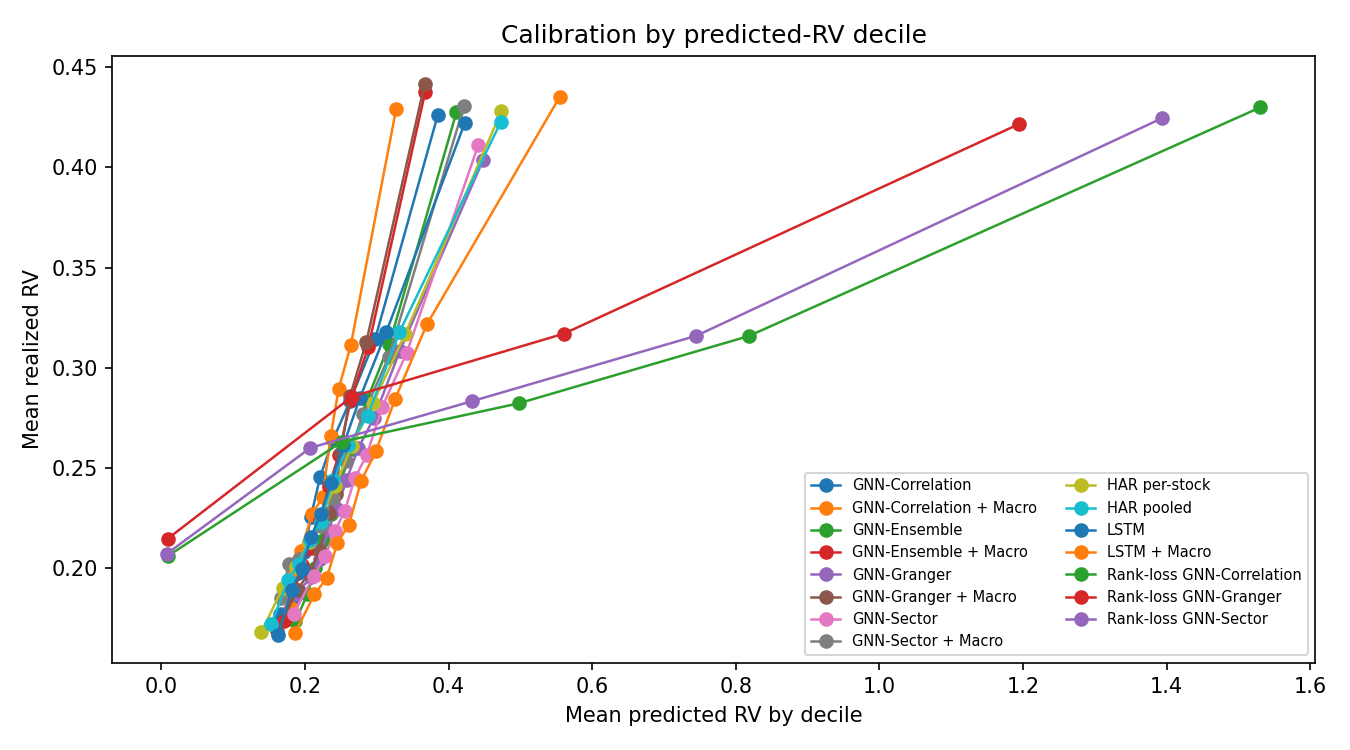

prediction_spread_by_week.png


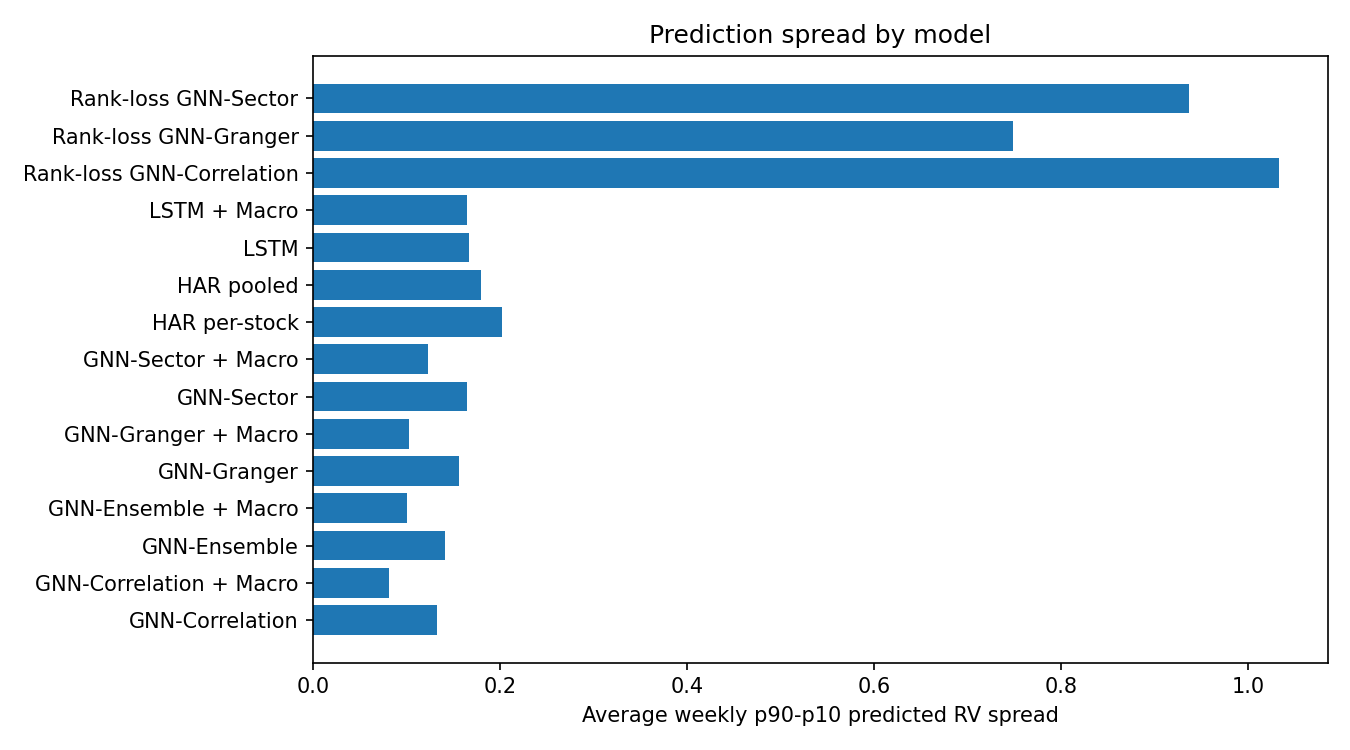

regime_breakdown_mse.png


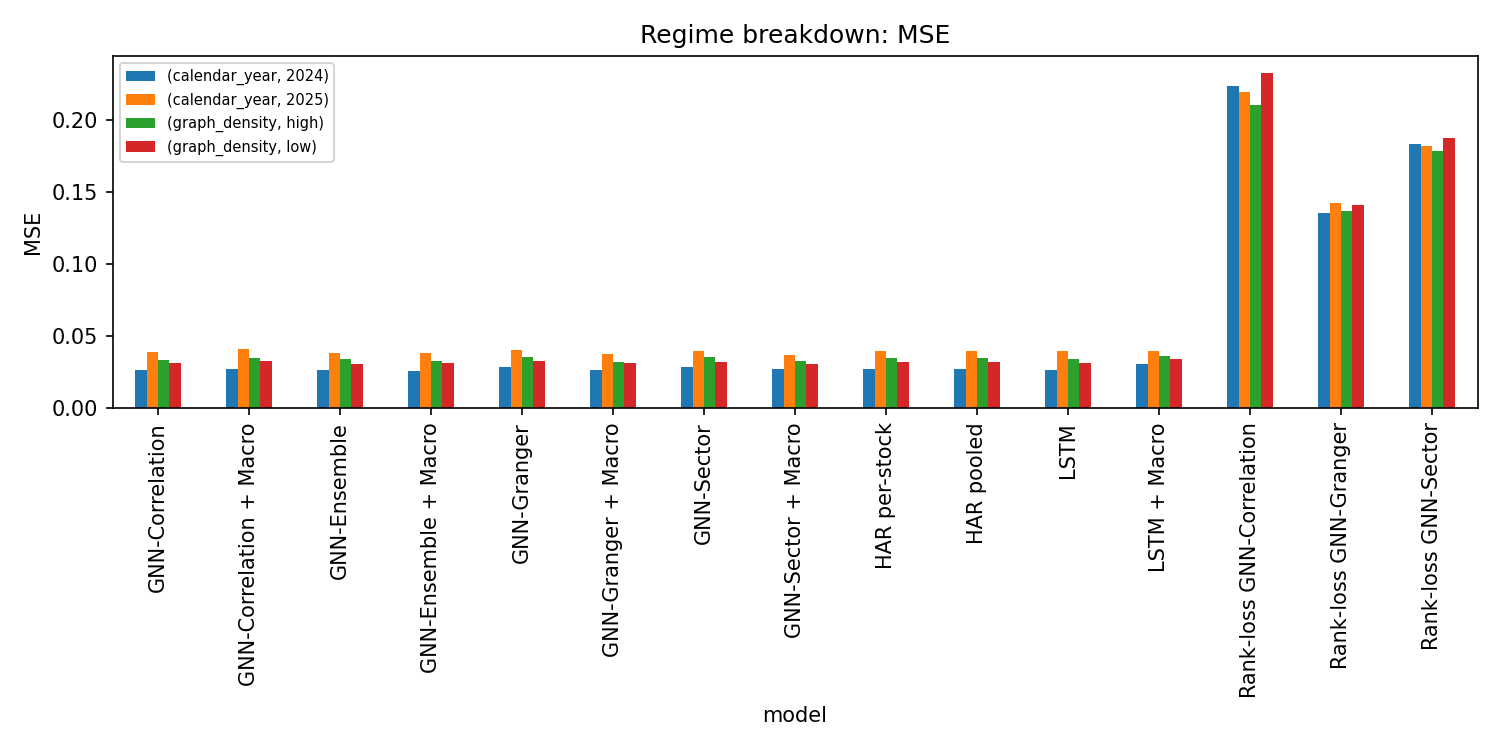

within_sector_rank_ic.png


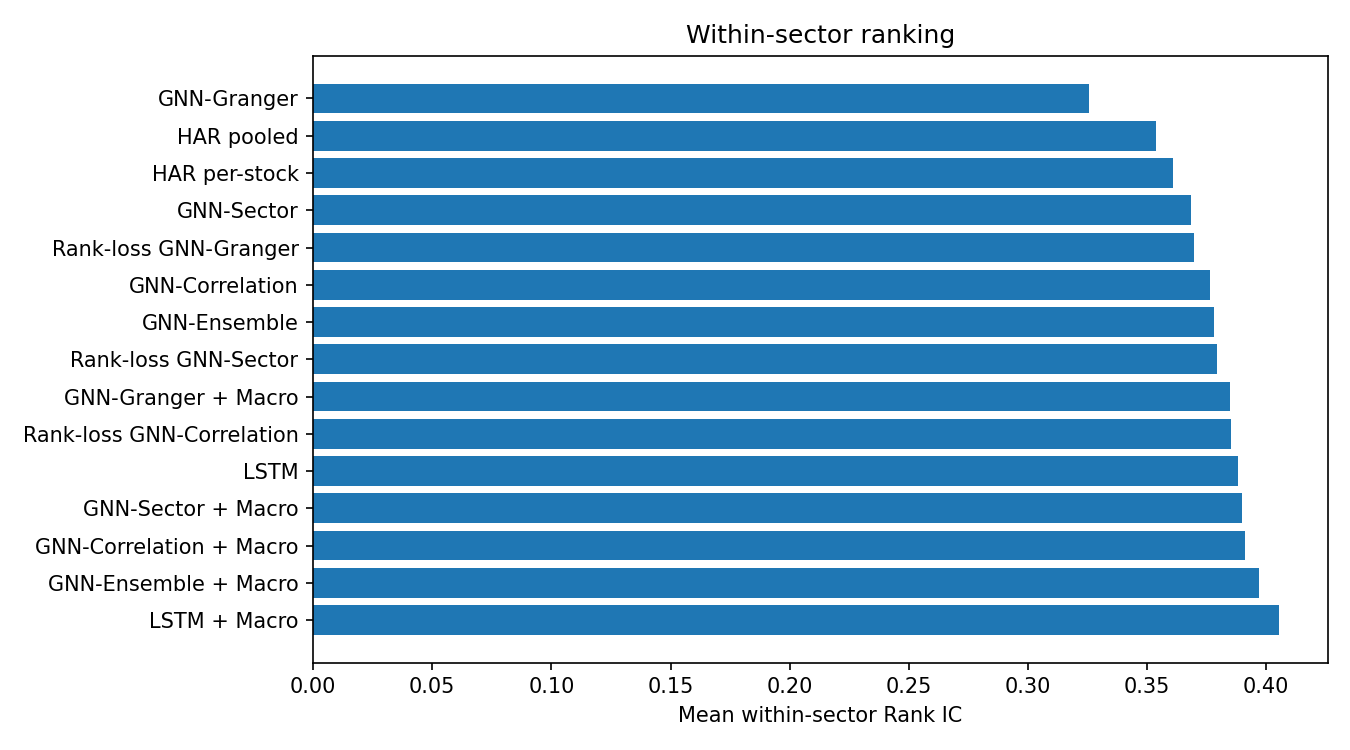

In [14]:
# STEP5_DIAGNOSTICS_FIGURES
from IPython.display import Image, display
from pathlib import Path

figures_dir = Path('../data/results/figures')
for filename in [
    'calibration_deciles.png',
    'prediction_spread_by_week.png',
    'regime_breakdown_mse.png',
    'within_sector_rank_ic.png',
]:
    print(filename)
    display(Image(filename=str(figures_dir / filename)))

# STEP7_MACRO_EVAL_START
## Step 7 - Macro Feature Model Evaluation

This section uses the experiment registry as the source of truth for baseline and macro-feature prediction artifacts, then refreshes the main ML, ranking, and calibration tables with both model sets.

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

import config
from src.diagnostics import compute_calibration_diagnostics
from src.model_artifacts import (
    compute_macro_evaluation_artifacts,
    load_predictions_from_registry,
    load_step7_prediction_registry,
    paired_macro_deltas,
)

results_dir = Path(config.DATA_RESULTS_DIR)
features_dir = Path(config.DATA_FEATURES_DIR)
raw_dir = Path(config.DATA_RAW_DIR)
figures_dir = Path(config.FIGURES_DIR)
figures_dir.mkdir(parents=True, exist_ok=True)

paths = compute_macro_evaluation_artifacts(
    results_dir=results_dir,
    features_dir=features_dir,
    raw_dir=raw_dir,
)
registry = load_step7_prediction_registry(results_dir)
predictions = load_predictions_from_registry(registry)
target = pd.read_parquet(features_dir / 'target.parquet')
target.index = pd.to_datetime(target.index)
calibration, calibration_bins = compute_calibration_diagnostics(predictions, target)
calibration.to_csv(results_dir / 'calibration_summary.csv', index=False)
calibration_bins.to_csv(results_dir / 'calibration_bins.csv', index=False)
calibration_deltas = paired_macro_deltas(
    calibration.set_index('model'),
    ['calibration_slope', 'avg_weekly_prediction_spread_p90_p10', 'spearman_rank_ic'],
)
calibration_deltas.to_csv(results_dir / 'macro_calibration_deltas.csv', index=False)

print('Step 7 artifacts refreshed:')
for name, path in paths.items():
    print(f'  {name}: {path}')
print('  calibration: data/results/calibration_summary.csv')
print('  calibration_deltas: data/results/macro_calibration_deltas.csv')

Step 7 artifacts refreshed:
  registry: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\macro_evaluation_registry.csv
  ml_metrics: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\ml_metrics_table.csv
  rank_ic: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\rank_ic_table.csv
  macro_ml_deltas: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\macro_ml_metric_deltas.csv
  macro_rank_deltas: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\macro_rank_ic_deltas.csv
  calibration: data/results/calibration_summary.csv
  calibration_deltas: data/results/macro_calibration_deltas.csv


In [16]:
ml = pd.read_csv(results_dir / 'ml_metrics_table.csv', index_col='model')
rank = pd.read_csv(results_dir / 'rank_ic_table.csv', index_col='model')
ml_deltas = pd.read_csv(results_dir / 'macro_ml_metric_deltas.csv')
rank_deltas = pd.read_csv(results_dir / 'macro_rank_ic_deltas.csv')

print('Registry-selected model artifacts')
display(registry[['experiment_id', 'model_name', 'feature_version', 'graph_type', 'loss_type', 'prediction_path']])

print('ML metrics with macro models included')
display(ml.style.format({'mse': '{:.6f}', 'mae': '{:.6f}', 'r2': '{:.4f}', 'da': '{:.4f}'}))

print('Macro minus matched-baseline ML metric deltas')
display(ml_deltas.style.format(precision=6))

print('Rank IC metrics with macro models included')
display(rank.style.format(precision=4))

print('Macro minus matched-baseline ranking deltas')
display(rank_deltas.style.format(precision=6))

print('Macro minus matched-baseline calibration deltas')
display(calibration_deltas.style.format(precision=6))

Registry-selected model artifacts


,experiment_id,model_name,feature_version,graph_type,loss_type,prediction_path
0,baseline_har_per_stock,HAR per-stock,har_realized_volatility_lags_v1,none,squared_error,data/results/test_preds_har.parquet
1,baseline_har_pooled,HAR pooled,har_realized_volatility_lags_v1,none,squared_error,data/results/test_preds_har_pooled.parquet
2,baseline_lstm,LSTM,stock_features_v1,none,mse,data/results/test_preds_lstm.parquet
3,baseline_gnn_correlation,GNN-Correlation,stock_features_v1,correlation,mse,data/results/test_preds_gnn_corr.parquet
4,baseline_gnn_sector,GNN-Sector,stock_features_v1,sector,mse,data/results/test_preds_gnn_sector.parquet
5,baseline_gnn_granger,GNN-Granger,stock_features_v1,granger,mse,data/results/test_preds_gnn_granger.parquet
6,baseline_gnn_ensemble,GNN-Ensemble,stock_features_v1,correlation+sector+granger,mse,data/results/test_preds_gnn_ensemble.parquet
7,macro_lstm,LSTM + Macro,stock_features_plus_regime_v1,none,mse,data/results/test_preds_lstm_macro.parquet
8,macro_gnn_correlation,GNN-Correlation + Macro,stock_features_plus_regime_v1,correlation,mse,data/results/test_preds_gnn_corr_macro.parquet
9,macro_gnn_sector,GNN-Sector + Macro,stock_features_plus_regime_v1,sector,mse,data/results/test_preds_gnn_sector_macro.parquet


ML metrics with macro models included


,mse,mae,r2,da
model,,,,
GNN-Granger + Macro,0.031439,0.107706,0.1682,0.7136
GNN-Sector + Macro,0.031508,0.110650,0.1664,0.7043
GNN-Ensemble + Macro,0.031598,0.107269,0.1640,0.7148
GNN-Ensemble,0.032012,0.112685,0.1531,0.7004
GNN-Correlation,0.032191,0.107638,0.1484,0.7122
LSTM,0.032424,0.109583,0.1422,0.7088
HAR per-stock,0.032858,0.112913,0.1307,0.7070
HAR pooled,0.033104,0.113265,0.1242,0.7030
GNN-Correlation + Macro,0.033383,0.107337,0.1168,0.7164


Macro minus matched-baseline ML metric deltas


...

,mean_ic,ic_std,ic_tstat,ic_pvalue,ic_ir,n_weeks,pct_positive,top_quartile_hit_rate,pairwise_accuracy
model,,,,,,,,,
LSTM + Macro,0.4470,0.1060,42.7945,0.0000,4.2167,103,1.0000,0.5074,0.6550
GNN-Ensemble + Macro,0.4378,0.1113,39.9349,0.0000,3.9349,103,1.0000,0.5013,0.6528
GNN-Correlation + Macro,0.4316,0.1117,39.2259,0.0000,3.8650,103,1.0000,0.4938,0.6423
GNN-Granger + Macro,0.4295,0.1057,41.2476,0.0000,4.0642,103,1.0000,0.4936,0.6482
LSTM,0.4288,0.0983,44.2754,0.0000,4.3626,103,1.0000,0.4990,0.6484
GNN-Sector + Macro,0.4278,0.1111,39.0752,0.0000,3.8502,103,1.0000,0.4970,0.6466
GNN-Correlation,0.4165,0.1211,34.9116,0.0000,3.4399,103,1.0000,0.4919,0.6448
GNN-Ensemble,0.4162,0.1164,36.3019,0.0000,3.5769,103,1.0000,0.4936,0.6451
HAR per-stock,0.4049,0.1166,35.2453,0.0000,3.4728,103,1.0000,0.4859,0.6407


Macro minus matched-baseline ranking deltas


,baseline_model,macro_model,baseline_mean_ic,macro_mean_ic,delta_mean_ic,baseline_ic_ir,macro_ic_ir,delta_ic_ir,baseline_top_quartile_hit_rate,macro_top_quartile_hit_rate,delta_top_quartile_hit_rate,baseline_pairwise_accuracy,macro_pairwise_accuracy,delta_pairwise_accuracy
0,LSTM,LSTM + Macro,0.428819,0.447012,0.018193,4.362584,4.216672,-0.145912,0.498996,0.507365,0.008370,0.648435,0.655022,0.006587
1,GNN-Correlation,GNN-Correlation + Macro,0.416509,0.431627,0.015118,3.439945,3.865044,0.425099,0.491881,0.493806,0.001925,0.644850,0.642297,-0.002553
2,GNN-Sector,GNN-Sector + Macro,0.382567,0.427789,0.045222,3.399371,3.850190,0.450819,0.478658,0.496987,0.018329,0.633046,0.646565,0.013519
3,GNN-Granger,GNN-Granger + Macro,0.374944,0.429478,0.054533,3.663010,4.064242,0.401233,0.472631,0.493555,0.020924,0.629316,0.648191,0.018874
4,GNN-Ensemble,GNN-Ensemble + Macro,0.416249,0.437834,0.021585,3.576932,3.934901,0.357969,0.493639,0.501255,0.007616,0.645078,0.652820,0.007742


Macro minus matched-baseline calibration deltas


,baseline_model,macro_model,baseline_calibration_slope,macro_calibration_slope,delta_calibration_slope,baseline_avg_weekly_prediction_spread_p90_p10,macro_avg_weekly_prediction_spread_p90_p10,delta_avg_weekly_prediction_spread_p90_p10,baseline_spearman_rank_ic,macro_spearman_rank_ic,delta_spearman_rank_ic
0,LSTM,LSTM + Macro,0.929696,0.682693,-0.247002,0.167289,0.165090,-0.002199,0.428819,0.447012,0.018193
1,GNN-Correlation,GNN-Correlation + Macro,1.182748,1.704704,0.521956,0.132478,0.081738,-0.050740,0.416509,0.431627,0.015118
2,GNN-Sector,GNN-Sector + Macro,0.932450,1.025958,0.093508,0.164246,0.122484,-0.041761,0.382567,0.427789,0.045222
3,GNN-Granger,GNN-Granger + Macro,0.873121,1.478146,0.605026,0.156416,0.102986,-0.053430,0.374944,0.429478,0.054533
4,GNN-Ensemble,GNN-Ensemble + Macro,1.158102,1.440601,0.282499,0.141022,0.100902,-0.040121,0.416249,0.437834,0.021585


Saved figure: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\figures\macro_model_evaluation_summary.png


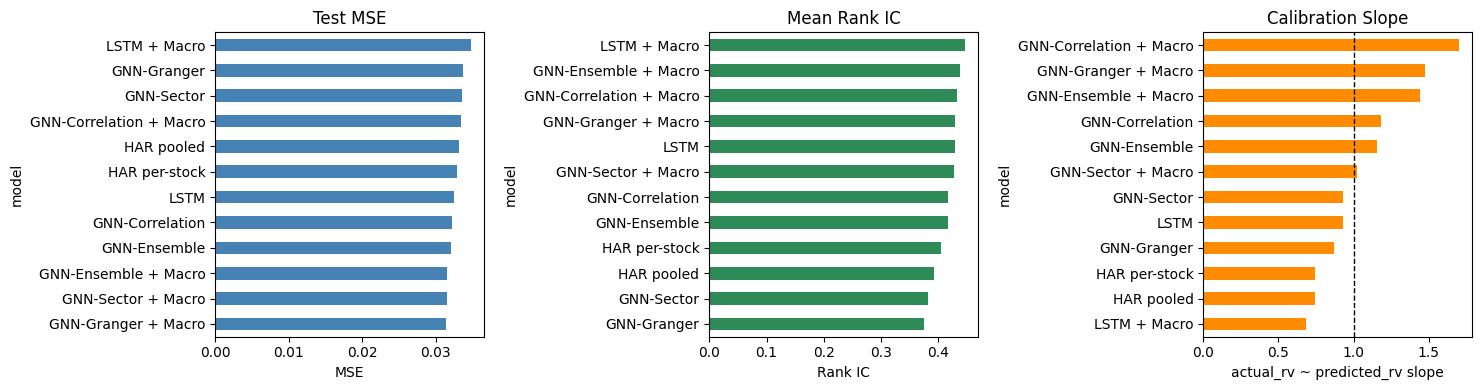

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ml['mse'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Test MSE')
axes[0].set_xlabel('MSE')

rank['mean_ic'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Mean Rank IC')
axes[1].set_xlabel('Rank IC')

cal_plot = calibration.set_index('model')['calibration_slope'].sort_values()
cal_plot.plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].axvline(1.0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Calibration Slope')
axes[2].set_xlabel('actual_rv ~ predicted_rv slope')

fig.tight_layout()
fig_path = figures_dir / 'macro_model_evaluation_summary.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved figure: {fig_path}')
plt.show()

# STEP7_MACRO_EVAL_END